# Streaming fresh minibatches

The memorization benchmark reused one minibatch for the whole run, so it measured raw
optimization power on a fixed objective. Here I draw a fresh minibatch every step
instead, so the run is actually training on CIFAR-10 and the question becomes
generalization: how low does the held-out loss go, and how fast? I compare the
trust-region optimizer against plain SGD, both on gelu and with the settings that
worked best in the memorization benchmark, because those are the ones worth carrying
over. I track the loss on a fixed held-out probe batch rather than the training loss,
because the training loss is measured on a different minibatch every step and is too
noisy to read.

## The configuration

The model and data match the memorization benchmark exactly, and the only change is
that I dropped `--reuse-batch`, so a new minibatch is drawn every step:

```
--image-size 8 --hidden-dim 8 --num-layers 16 --batch-size 32 --seed 0 --data-dir ./data
```

There are two runs, both on gelu. The trust-region run uses the dense subproblem solver
with the tuned radius, `--mode trust-region --tr-solver dense --delta-init 1.0 --delta-max 100 --tr-eta 0.1 --num-steps 400`.
The SGD run uses `--mode sgd --lr 0.03 --num-steps 30000`, where the learning rate is the
one I tuned for gelu on the fixed batch, so both optimizers inherit their memorization
settings. The exact args live in `streaming/experiments.py`, which both `run.py` and
`plot.py` import.

## Running it

The figure below renders inline from the CSVs I committed. To regenerate the data, run
`python benchmarks/streaming/run.py` from the repo root using the project venv. That
script launches `src/train_newton.py` once per config, parses its per-step stderr, and
writes `streaming/results/<name>.csv` with columns
`step,train_loss,probe_loss,probe_accuracy,wall_clock_s`. The cell below then renders the
figure by importing `plot`.

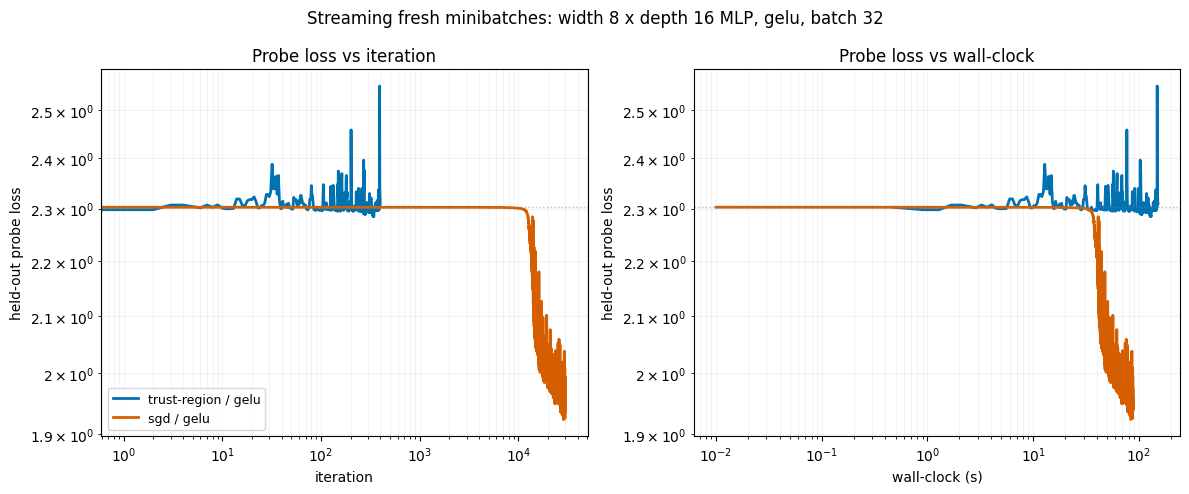

In [1]:
import pathlib, sys

for cand in (pathlib.Path.cwd() / "streaming",
             pathlib.Path.cwd() / "benchmarks" / "streaming"):
    if cand.exists():
        sys.path.insert(0, str(cand))
        break

%matplotlib inline
import plot

fig = plot.build_figure()

## What I found

| Run      | Method       | Best probe loss | Step at best | Wall-clock at best | Best probe acc |
|----------|--------------|-----------------|--------------|--------------------|----------------|
| tr_gelu  | trust-region | 2.2844          | 341          | 129.5 s            | 0.148          |
| sgd_gelu | sgd          | 1.9233          | 28660        | 84.2 s             | 0.270          |

The result flips from the memorization benchmark, because here SGD wins. SGD drives the
held-out probe loss down to 1.92, reaching 27% probe accuracy by 30000 steps, whereas
trust-region never gets below 2.28 and mostly thrashes around the random-guess loss of
ln(10) ≈ 2.30, so it barely learns at all. The two runs take very different iteration
counts, so the wall-clock panel is the fair comparison, and at roughly equal wall-clock
(about 130 s for trust-region's 400 steps against 84 s for SGD's 30000) SGD is already
far ahead.

This is the minibatch-noise effect from the stochastic-optimization literature. The
trust-region step is computed from one noisy minibatch and its acceptance ratio is
checked on that same batch, so it fits the curvature of a different objective every step,
and a second-order method loses its edge once the gradient and Hessian are dominated by
that noise. The memorization benchmark removed the noise by reusing one batch, which is
exactly why trust-region won there and loses here.